In [211]:
# ==========================================================
# ZOMATO RESTAURANT RATING PREDICTION - PROJECT TEMPLATE
# ==========================================================

import time

# --- 0. SCRIPT START ---
print("==========================================================")
print("Starting Zomato Rating Prediction script...")
script_start_time = time.time()

Starting Zomato Rating Prediction script...


In [212]:
from utility.utils import setup_autosave, save_plot
setup_autosave()

✅ Auto-save mode activated. Use plt.show('filename') to save automatically.


In [213]:
import time
# --- 1. IMPORT LIBRARIES ---
print("\n[Phase 1/8] Importing Libraries...")
phase_start_time = time.time()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings 
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
print(f"  > Libraries imported in {time.time() - phase_start_time:.2f}s")
 


[Phase 1/8] Importing Libraries...
  > Libraries imported in 0.00s


In [214]:
# --- 2. SETTINGS & CONFIGURATIONS ---
# Settings for plots and warnings
sns.set(style="whitegrid")
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')
# To display plots in a script environment, you might need plt.show() after each plot.
# %matplotlib inline is for Jupyter notebooks.


In [215]:
# --- 3. LOAD DATA ---
print("\n[Phase 2/8] Loading Data...")
phase_start_time = time.time()
file_path = '//Users/mac/Desktop/Desktop_Files/Projects/Zomato Restaurant Rating Prediction/raw data/zomato.csv'  # <-- IMPORTANT: Make sure this path is correct
try:
    df = pd.read_csv(file_path)
    print(f"  > Dataset loaded successfully from '{file_path}'.")
    print(f"  > Initial shape: {df.shape}")
    print(f"  > Phase 2 completed in {time.time() - phase_start_time:.2f}s")
except FileNotFoundError:
    print(f"  > ERROR: File not found at {file_path}. Please update the path.")
    # Exit or raise error if file not found
    df = pd.DataFrame() # Create empty df to avoid downstream errors if script continues



[Phase 2/8] Loading Data...
  > Dataset loaded successfully from '//Users/mac/Desktop/Desktop_Files/Projects/Zomato Restaurant Rating Prediction/raw data/zomato.csv'.
  > Initial shape: (51717, 17)
  > Phase 2 completed in 4.63s


In [216]:
if not df.empty:
    # --- 4. INITIAL DATA INSPECTION ---
    print("\n[Phase 3/8] Initial Data Inspection...")
    phase_start_time = time.time()
    print("  > First 5 rows of the dataset:")
    print(df.head())
    
    print("\n  > Data types and non-null counts:")
    df.info()
    
    # print("\nSummary statistics:") # This can be very verbose, uncomment if needed
    # print(df.describe(include='all'))
    
    print(f"\n  > Initial missing values count:\n{df.isnull().sum()}")
    print(f"  > Phase 3 completed in {time.time() - phase_start_time:.2f}s")
    


[Phase 3/8] Initial Data Inspection...
  > First 5 rows of the dataset:
                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Yes        Yes  4.1/5    77

In [217]:
# --- 5. DATA CLEANING & PREPROCESSING ---
print("\n[Phase 4/8] Data Cleaning & Preprocessing...")
phase_start_time = time.time()



[Phase 4/8] Data Cleaning & Preprocessing...


In [218]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [219]:
# 5.1. Drop Irrelevant/Redundant Columns
print("  > 5.1. Dropping irrelevant columns...")
columns_to_drop = ['url', 'cuisines', 'name', 'address', 'reviews_list', 'phone', 'menu_item', 'dish_liked', 'listed_in(city)', 'listed_in(type)']
columns_exist = [col for col in columns_to_drop if col in df.columns]
df.drop(columns=columns_exist, axis=1, inplace=True)


  > 5.1. Dropping irrelevant columns...


In [220]:
df.columns

Index(['online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type',
       'approx_cost(for two people)'],
      dtype='object')

In [221]:
df.shape

(51717, 7)

In [222]:
# 5.2. Handle Duplicates
print("  > 5.2. Handling duplicates...")
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"    > Removed {initial_rows - df.shape[0]} duplicate rows.")

  > 5.2. Handling duplicates...
    > Removed 30274 duplicate rows.


In [223]:
df.shape

(21443, 7)

In [224]:
# 5.3. Clean Specific Columns
print("  > 5.3. Cleaning specific columns ('rate', 'Cost', 'online_order', 'book_table')...")

if 'rate' in df.columns:
    df['rate'].replace(('NEW', '-'), np.nan, inplace=True)
    df['rate'] = df['rate'].astype(str).str.replace('/5', '').str.strip()
    df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

if 'approx_cost(for two people)' in df.columns:
    df.rename(columns={'approx_cost(for two people)': 'Cost'}, inplace=True)
    df['Cost'] = df['Cost'].astype(str).str.replace(',', '')
    df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce')

if 'online_order' in df.columns:
    df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})
if 'book_table' in df.columns:
    df['book_table'] = df['book_table'].map({'Yes': 1, 'No': 0})


  > 5.3. Cleaning specific columns ('rate', 'Cost', 'online_order', 'book_table')...


In [225]:
# 5.4. Handle Missing Values (Imputation)
print("  > 5.4. Handling missing values (Imputation)...")

if 'rate' in df.columns:
    median_rate = df['rate'].median()
    df['rate'].fillna(median_rate, inplace=True)
if 'Cost' in df.columns:
    median_cost = df['Cost'].median()
    df['Cost'].fillna(median_cost, inplace=True)
    df['Cost'] = df['Cost'].astype(int)
for col in ['location', 'rest_type', 'cuisines']:
    if col in df.columns and df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)
        
for col in ['online_order', 'book_table']:
    if col in df.columns and df[col].isnull().any():
       df[col].fillna(df[col].mode()[0], inplace=True)

  > 5.4. Handling missing values (Imputation)...


In [226]:
# 5.5. Rename Other Columns
df.rename(columns={'listed_in(type)': 'Type', 'reviews_list': 'Review'}, inplace=True)


In [227]:

# 5.6. Handle High Cardinality Columns
print("  > 5.6. Dropping high cardinality text columns ('Review', 'name')...")
columns_to_drop_high_card = ['Review', 'name']
columns_exist = [col for col in columns_to_drop_high_card if col in df.columns]
df.drop(columns=columns_exist, axis=1, inplace=True)

print(f"  > Shape after all preprocessing: {df.shape}")
print(f"  > Phase 4 completed in {time.time() - phase_start_time:.2f}s")


  > 5.6. Dropping high cardinality text columns ('Review', 'name')...
  > Shape after all preprocessing: (21443, 7)
  > Phase 4 completed in 0.30s


In [228]:

# --- 6. EXPLORATORY DATA ANALYSIS (EDA) ---
print("\n[Phase 5/8] Exploratory Data Analysis (plots are commented out)...")
phase_start_time = time.time()
# NOTE: Plots are best viewed in a Jupyter Notebook. 
# In a .py script, you must call plt.show() after each plot block to display them.
# 6.1. Univariate Analysis
# print("  > 6.1. Displaying Univariate Plots...")
# ... (Plotting code commented out as before) ...

# 6.2. Bivariate Analysis
# print("  > 6.2. Displaying Bivariate Plots...")
# ... (Plotting code commented out as before) ...

print("  > Plotting steps are commented out. Uncomment in script to generate visualizations.")
print(f"  > Phase 5 skipped/completed in {time.time() - phase_start_time:.2f}s")


[Phase 5/8] Exploratory Data Analysis (plots are commented out)...
  > Plotting steps are commented out. Uncomment in script to generate visualizations.
  > Phase 5 skipped/completed in 0.00s


In [229]:
# --- 7. FEATURE ENGINEERING & ENCODING ---
print("\n[Phase 6/8] Feature Engineering & Encoding...")
phase_start_time = time.time()
# 7.1. Feature Engineering: Group Rare Categories
print("  > 7.1. Applying feature engineering (grouping rare categories)...")
if 'cuisines' in df.columns:
    df['cuisine_count'] = df['cuisines'].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0)
# Group rare locations, rest_types, and cuisines
for col in ['location', 'rest_type', 'cuisines']:
    if col in df.columns:
        counts = df[col].value_counts()
        # Set a threshold (e.g., 20) for what constitutes a "rare" category
        threshold = 20 
        rare_categories = counts[counts < threshold].index
        print(f"    > Grouping {len(rare_categories)} rare categories in '{col}' into 'Other'.")
        df[col] = df[col].replace(rare_categories, 'Other')




[Phase 6/8] Feature Engineering & Encoding...
  > 7.1. Applying feature engineering (grouping rare categories)...
    > Grouping 18 rare categories in 'location' into 'Other'.
    > Grouping 48 rare categories in 'rest_type' into 'Other'.


In [230]:
df.columns

Index(['online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type',
       'Cost'],
      dtype='object')

🚀 Starting Outlier Detection and Correlation Analysis...
✅ Binary columns confirmed: ['online_order', 'book_table']
✅ Label columns confirmed: ['location', 'rest_type']

🔎 Detecting Outliers using IQR Method...
• rate: Lower = 388, Upper = 70
• votes: Lower = 0, Upper = 2845
• Cost: Lower = 0, Upper = 1485
✅ Outliers capped using IQR bounds.
✅ Shape after outlier treatment: (21443, 7)

📊 Computing Correlations with 'rate'...

🔍 Top Correlations with 'rate':
rate            1.000000
votes           0.576696
book_table      0.421697
Cost            0.408846
location        0.056914
online_order    0.036051
rest_type      -0.212283
Name: rate, dtype: float64
✅ Auto-saved: visualizations/Correlation of Features with 'rate' (Post Outlier Treatment).png


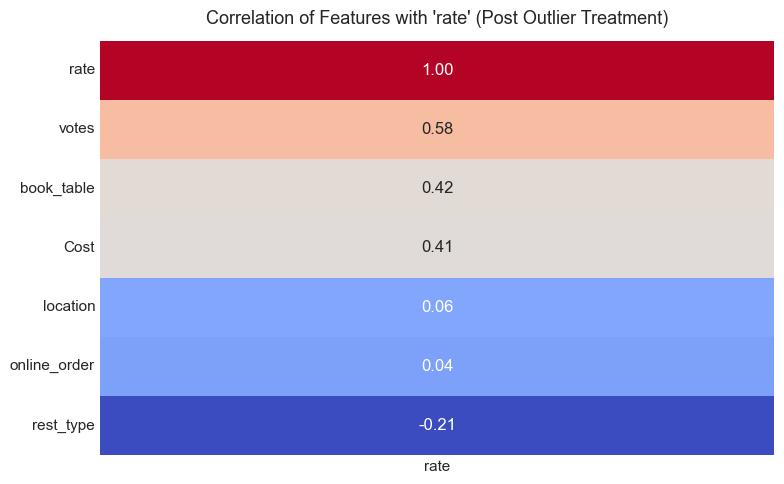


✅ Outlier Detection + Correlation Phase completed in 0.44s


In [231]:
# ============================================================
# 7. Outlier Detection + Optimized Correlation Analysis
# ============================================================
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

phase_start_time = time.time()
print("🚀 Starting Outlier Detection and Correlation Analysis...")

# ------------------------------------------------------------
# Step 1. Ensure Binary & Label Encoded Columns (if not already)
# ------------------------------------------------------------
binary_map = {'Yes': 1, 'No': 0}
binary_cols = ['online_order', 'book_table']

for col in binary_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].replace(binary_map).astype(int)
print(f"✅ Binary columns confirmed: {binary_cols}")

label_cols = ['location', 'rest_type']
le = LabelEncoder()

for col in label_cols:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))
print(f"✅ Label columns confirmed: {label_cols}")

# ------------------------------------------------------------
# Step 2. Outlier Detection and Treatment (IQR Method)
# ------------------------------------------------------------
print("\n🔎 Detecting Outliers using IQR Method...")

numeric_cols = ['rate', 'votes', 'Cost']
outlier_summary = []

for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    lower_outliers = (df[col] < lower).sum()
    upper_outliers = (df[col] > upper).sum()

    print(f"• {col}: Lower = {lower_outliers}, Upper = {upper_outliers}")
    outlier_summary.append({
        'Feature': col,
        'Lower_Outliers': lower_outliers,
        'Upper_Outliers': upper_outliers
    })

# Optional: Cap outliers to IQR limits instead of dropping
for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print("✅ Outliers capped using IQR bounds.")

# ------------------------------------------------------------
# Step 3. Prepare Cleaned Copy
# ------------------------------------------------------------
df_cleaned = df.copy()
print(f"✅ Shape after outlier treatment: {df_cleaned.shape}")

# ------------------------------------------------------------
# Step 4. Compute Feature Correlations
# ------------------------------------------------------------
print("\n📊 Computing Correlations with 'rate'...")
corr_rate = df_cleaned.corr(numeric_only=True)['rate'].sort_values(ascending=False)

print("\n🔍 Top Correlations with 'rate':")
print(corr_rate.head(10))

# ------------------------------------------------------------
# Step 5. Visualize Correlation Heatmap
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_rate.to_frame(),
    annot=True,
    cmap='coolwarm',
    cbar=False,
    fmt=".2f"
)
plt.title("Correlation of Features with 'rate' (Post Outlier Treatment)", fontsize=13, pad=12)
plt.tight_layout()
plt.show("Correlation of Features with 'rate' (Post Outlier Treatment)")

# ------------------------------------------------------------
# Step 6. Summary Log
# ------------------------------------------------------------
print(f"\n✅ Outlier Detection + Correlation Phase completed in {time.time() - phase_start_time:.2f}s")


In [238]:
df.sample(2)

,online_order,book_table,rate,votes,location,rest_type,Cost
6958,0,1,3.1,19,9,38,400
12317,1,1,4.4,638,45,14,1300


- votes and book_table followed by cost has highest correlation

In [239]:
# --- 8. MODEL BUILDING & EVALUATION ---
print("\n[Phase 7/8] Model Building & Evaluation...")
phase_start_time = time.time()

# 8.1. Prepare Data for Modeling (Splitting)
print("  > 8.1. Splitting data into training and testing sets...")
X = df.drop('rate', axis=1)
y = df['rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"    > Training set shape (X, y): {X_train.shape}, {y_train.shape}")
print(f"    > Testing set shape (X, y): {X_test.shape}, {y_test.shape}")

# Save the test sets for the evaluation script
print("    > Saving test data to 'X_test_data.csv' and 'y_test_data.csv'...")
X_test.to_csv('X_test_data.csv', index=False)
y_test.to_csv('y_test_data.csv', index=False)


[Phase 7/8] Model Building & Evaluation...
  > 8.1. Splitting data into training and testing sets...
    > Training set shape (X, y): (17154, 6), (17154,)
    > Testing set shape (X, y): (4289, 6), (4289,)
    > Saving test data to 'X_test_data.csv' and 'y_test_data.csv'...


In [246]:
# 8.2. Define Evaluation Function
def evaluate_model(y_true, y_pred, model_name):
    """Evaluate model performance with R2, MAE, RMSE."""
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5   # ✅ Compatible fix
    print(f"\n📊 --- {model_name} Evaluation ---")
    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print("  " + "-" * 25)
    return {"Model": model_name, "R2": r2, "MAE": mae, "RMSE": rmse}

In [247]:
# 8.3. Train & Evaluate Models
print("\n  > 8.3. Training and evaluating baseline models...")
    


  > 8.3. Training and evaluating baseline models...


In [248]:
# Linear Regression (Baseline)
print("    > Training Linear Regression...")
model_fit_start = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(f"    > Linear Regression trained in {time.time() - model_fit_start:.2f}s")
joblib.dump(lr, 'linear_regression_model.pkl') # Save the model
evaluate_model(y_test, y_pred_lr, 'Linear Regression')

    > Training Linear Regression...
    > Linear Regression trained in 0.01s

📊 --- Linear Regression Evaluation ---
R² Score : 0.3411
MAE      : 0.2634
RMSE     : 0.3351
  -------------------------


{'Model': 'Linear Regression',
 'R2': 0.3411044521751311,
 'MAE': 0.26342566768197756,
 'RMSE': 0.3350773446287305}

In [249]:

# Decision Tree
print("\n    > Training Decision Tree...")
model_fit_start = time.time()
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print(f"    > Decision Tree trained in {time.time() - model_fit_start:.2f}s")
joblib.dump(dt, 'decision_tree_model.pkl') # Save the model
evaluate_model(y_test, y_pred_dt, 'Decision Tree')


    > Training Decision Tree...
    > Decision Tree trained in 0.07s

📊 --- Decision Tree Evaluation ---
R² Score : 0.5477
MAE      : 0.1343
RMSE     : 0.2776
  -------------------------


{'Model': 'Decision Tree',
 'R2': 0.5476609574136383,
 'MAE': 0.13427594109247828,
 'RMSE': 0.2776315488145159}

In [250]:
# Random Forest
print("\n    > Training Random Forest (n_estimators=100)...")
model_fit_start = time.time()
rf = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"    > Random Forest trained in {time.time() - model_fit_start:.2f}s")
joblib.dump(rf, 'random_forest_model.pkl') # Save the model
evaluate_model(y_test, y_pred_rf, 'Random Forest')


    > Training Random Forest (n_estimators=100)...
    > Random Forest trained in 0.95s

📊 --- Random Forest Evaluation ---
R² Score : 0.7287
MAE      : 0.1351
RMSE     : 0.2150
  -------------------------


{'Model': 'Random Forest',
 'R2': 0.7286789956231425,
 'MAE': 0.1351186748347993,
 'RMSE': 0.2150198163932597}

In [ ]:
# XGBoost
print("\n    > Training XGBoost (default params)...")
model_fit_start = time.time()
xgb = XGBRegressor(random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(f"    > XGBoost trained in {time.time() - model_fit_start:.2f}s")
joblib.dump(xgb, 'xgboost_model.pkl') # Save the model
evaluate_model(y_test, y_pred_xgb, 'XGBoost') 


    > Training XGBoost (default params)...
    > XGBoost trained in 0.19s

📊 --- XGBoost Evaluation ---
R² Score : 0.6113
MAE      : 0.1806
RMSE     : 0.2574
  -------------------------


{'Model': 'XGBoost',
 'R2': 0.6113001512874519,
 'MAE': 0.18056117642812444,
 'RMSE': 0.25736172833232546}